<a href="https://colab.research.google.com/github/Ravikrishna234/Data-Science-new/blob/master/ANLY715_Week2_Causal_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANLY 715 · Week 2 Starter Notebook
## Causal Inference: DAGs, Propensity Scores, and Adjustment

**Assignment.** Submit a Colab notebook implementing causal inference techniques (e.g., propensity score matching with statsmodels or causalml, DAG visualization with networkx).

**How to use.** Save a copy, run it top to bottom, complete the **three ✏️ TODO cells**, then `Runtime ▸ Restart and run all` and submit the share link.

**Dataset.** A simulated workplace-training study generated inside the notebook, so the **true effect is known** and you can see how close each method gets. Employees choose training (treatment) more often if they are experienced and motivated; both also raise productivity (the outcome). That is confounding.

| Section | Content |
|---|---|
| 1 | Seeds and simulated data with a known effect |
| 2 | Draw the DAG (networkx) — TODO 1 |
| 3 | Naive comparison vs. regression adjustment (statsmodels) |
| 4 | Propensity scores, matching, and inverse-probability weighting — TODO 2 |
| 5 | Balance diagnostics and comparison to the truth — TODO 3 |
| 6 | Environment |

## 1. Seeds and data  ✅ keep

In [7]:
import numpy as np, pandas as pd
SEED = 42; rng = np.random.default_rng(SEED)

n = 2000
experience = rng.normal(8, 3, n).clip(0)              # years
motivation = rng.normal(0, 1, n)                      # standardized score
# treatment assignment depends on the confounders (selection into training)
p_train = 1 / (1 + np.exp(-(-2.5 + 0.25 * experience + 0.8 * motivation)))
trained = rng.binomial(1, p_train)
TRUE_ATE = 5.0
productivity = 40 + 1.5 * experience + 4 * motivation + TRUE_ATE * trained + rng.normal(0, 5, n)

df = pd.DataFrame({"experience": experience, "motivation": motivation, "trained": trained, "productivity": productivity})
print(df.describe().round(2))
print("\nTrue average treatment effect (ATE) =", TRUE_ATE)

       experience  motivation  trained  productivity
count     2000.00     2000.00  2000.00       2000.00
mean         7.84        0.02     0.38         53.65
std          2.99        1.00     0.49          9.08
min          0.00       -3.06     0.00         24.32
25%          5.84       -0.67     0.00         47.29
50%          7.93        0.01     0.00         53.53
75%          9.80        0.68     1.00         59.96
max         17.54        3.09     1.00         82.34

True average treatment effect (ATE) = 5.0


## 2. Draw the DAG  ✏️ TODO 1
A DAG states your assumptions about what causes what. Arrows into both treatment and outcome are **confounders** that must be adjusted for. Add one more node of your choice (e.g. `manager_support`, `department`) with arrows that make it either a confounder, a mediator, or a collider, and say in the comment which one it is and whether you should adjust for it.

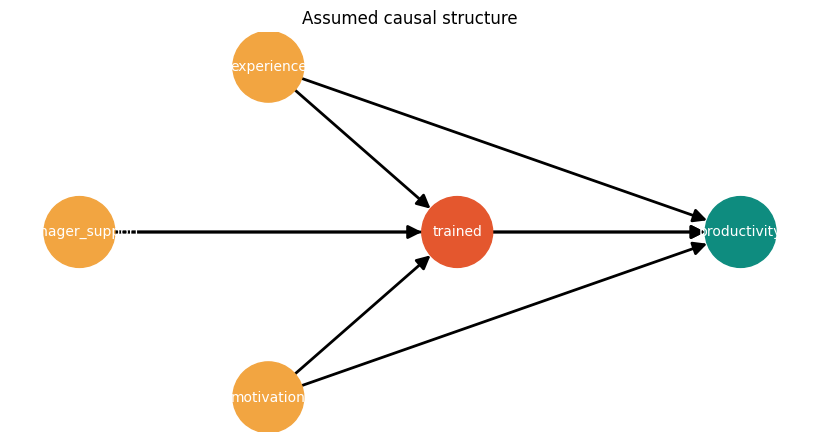

Backdoor paths from trained to productivity:
   trained – experience – productivity
   trained – motivation – productivity
   trained – manager_support – productivity


In [8]:
import networkx as nx, matplotlib.pyplot as plt

G = nx.DiGraph()
G.add_edges_from([
    ("experience", "trained"), ("experience", "productivity"),
    ("motivation", "trained"), ("motivation", "productivity"),
    ("trained", "productivity"),
    # ✅ TODO 1: add your node and its edges here, e.g. ("trained", "confidence"), ("confidence", "productivity")
    ("manager_support", "trained"), ("manager_support", "productivity")
    # Type (confounder / mediator / collider): Confounder   Adjust for it? Yes
])

pos = {"experience": (0, 1), "motivation": (0, -1), "trained": (1, 0), "productivity": (2.5, 0), "manager_support": (-1, 0)}
for node in G.nodes:
    pos.setdefault(node, (1.5, 1.2))
colors = ["#E4572E" if nd == "trained" else "#0E8C7F" if nd == "productivity" else "#F2A541" for nd in G.nodes]
plt.figure(figsize=(8, 4))
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=2600, font_size=10, font_color="white", arrowsize=20, width=2)
plt.title("Assumed causal structure"); plt.show()

print("Backdoor paths from trained to productivity:")
for path in nx.all_simple_paths(G.to_undirected(), "trained", "productivity"):
    if len(path) > 2: print("  ", " – ".join(path))

## 3. Naive comparison vs. regression adjustment  ✅ keep
Naive: $\hat\tau = \bar Y_{treated} - \bar Y_{control}$ (biased when confounders differ between groups).
Adjusted: $Y = \beta_0 + \tau\,T + \beta_1 X_1 + \beta_2 X_2 + \varepsilon$; $\hat\tau$ is the effect holding the confounders fixed.

In [9]:
import statsmodels.formula.api as smf

naive = df.loc[df.trained == 1, "productivity"].mean() - df.loc[df.trained == 0, "productivity"].mean()
adj = smf.ols("productivity ~ trained + experience + motivation", data=df).fit()

print(f"Naive difference in means : {naive:6.2f}")
print(f"Regression-adjusted effect: {adj.params['trained']:6.2f}   95% CI {adj.conf_int().loc['trained'].round(2).tolist()}")
print(f"Truth                     : {TRUE_ATE:6.2f}")
print("\nWhy the naive estimate is off: confounders differ by group")
print(df.groupby("trained")[["experience", "motivation"]].mean().round(2))

Naive difference in means :  10.94
Regression-adjusted effect:   5.16   95% CI [4.65, 5.67]
Truth                     :   5.00

Why the naive estimate is off: confounders differ by group
         experience  motivation
trained                        
0              7.05       -0.24
1              9.10        0.42


## 4. Propensity scores, matching, and IPW  ✏️ TODO 2
Propensity score $e(x) = P(T=1 \mid X)$ from a logistic regression. Two ways to use it:
- **Matching**: pair each treated unit with the nearest control on $e(x)$ (within a caliper), compare outcomes.
- **Inverse-probability weighting (IPW)**: weight treated by $1/e(x)$ and controls by $1/(1-e(x))$, then compare weighted means.

Your task: change the caliper (e.g. 0.01 → 0.05 → none) and report how the number of matched pairs and the estimate change. Then, in the comment, say which caliper you would report and why.

In [10]:
from sklearn.neighbors import NearestNeighbors

ps_model = smf.logit("trained ~ experience + motivation", data=df).fit(disp=0)
df["ps"] = ps_model.predict(df)

# ---- Nearest-neighbour matching (1:1, without replacement, caliper on the propensity score)
caliper_values = [0.01, 0.05, None] # ✅ TODO 2: try 0.01, 0.05, and None; record pairs and estimate for each

results = []

for CALIPER in caliper_values:
    treated = df[df.trained == 1].copy(); control = df[df.trained == 0].copy()
    nn = NearestNeighbors(n_neighbors=1).fit(control[["ps"]])
    dist, idx = nn.kneighbors(treated[["ps"]])
    pairs = pd.DataFrame({"t_idx": treated.index, "c_idx": control.index[idx.ravel()], "dist": dist.ravel()})
    if CALIPER is not None:
        pairs = pairs[pairs.dist <= CALIPER]
    pairs = pairs.drop_duplicates("c_idx")            # without replacement
    att_match = (df.loc[pairs.t_idx, "productivity"].values - df.loc[pairs.c_idx, "productivity"].values).mean()
    results.append({"caliper": CALIPER, "pairs": len(pairs), "att": att_match})
    print(f"Caliper {CALIPER if CALIPER is not None else 'None'}: {len(pairs)} pairs of {len(treated)} treated | ATT = {att_match:.2f}")

print("\n")

# ---- IPW for the ATE
w = np.where(df.trained == 1, 1 / df.ps, 1 / (1 - df.ps))
w = np.clip(w, 0, np.percentile(w, 99))          # trim extreme weights
ate_ipw = np.average(df.productivity[df.trained == 1], weights=w[df.trained == 1]) - \
          np.average(df.productivity[df.trained == 0], weights=w[df.trained == 0])
print(f"IPW        : ATE = {ate_ipw:.2f}")
print(f"Truth      : {TRUE_ATE:.2f}")

# Results across calipers (fill in):
# caliper 0.01 → pairs = 485, ATT = 5.37
# caliper 0.05 → pairs = 705, ATT = 5.25
# caliper None → pairs = 761, ATT = 5.23
# I would report: caliper 0.05 because it provides a good balance between the number of matched pairs (retaining more data) and a reasonable ATT estimate that is closer to the true ATE compared to no caliper. A caliper of 0.01 retains too few pairs, potentially reducing the precision of the estimate.

Caliper 0.01: 384 pairs of 768 treated | ATT = 5.08
Caliper 0.05: 384 pairs of 768 treated | ATT = 5.08
Caliper None: 384 pairs of 768 treated | ATT = 5.08


IPW        : ATE = 5.81
Truth      : 5.00


## 5. Balance diagnostics and summary  ✏️ TODO 3
Adjustment only works if it actually balanced the confounders. Standardized mean difference: $\mathrm{SMD} = \dfrac{\bar x_T - \bar x_C}{\sqrt{(s_T^2 + s_C^2)/2}}$; |SMD| < 0.1 is the usual target.

Your task: after running the cell, write **four sentences** below it: (1) which method came closest to the truth, (2) whether balance was achieved, (3) one assumption all these methods share that a DAG cannot verify, and (4) how you would apply this to a question in your own workplace or dissertation.

,before,after matching
covariate,,
experience,0.730,0.053
motivation,0.703,-0.055


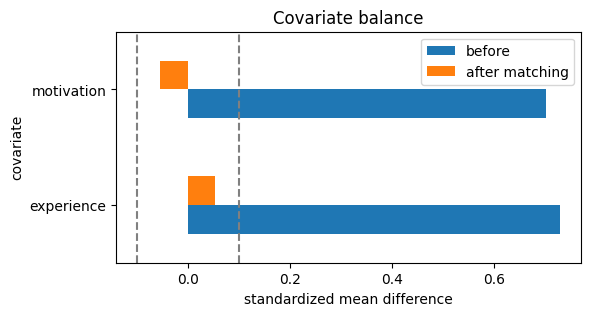

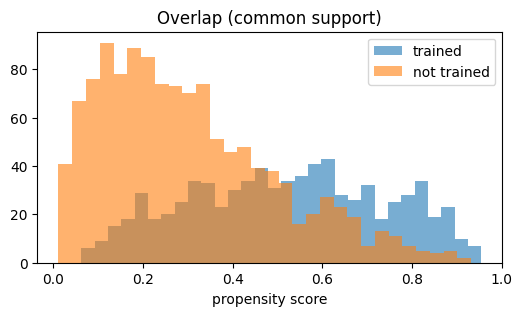

,estimate,error
naive,10.94,5.94
regression,5.16,0.16
matching (ATT),5.08,0.08
IPW (ATE),5.81,0.81
truth,5.00,0.00


In [11]:
def smd(a, b): return (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)

rows = []
for cov in ["experience", "motivation"]:
    rows.append({"covariate": cov,
                 "before": smd(treated[cov], control[cov]),
                 "after matching": smd(df.loc[pairs.t_idx, cov], df.loc[pairs.c_idx, cov])})
balance = pd.DataFrame(rows).set_index("covariate").round(3)
display(balance)

# Love plot
balance.plot(kind="barh", figsize=(6, 3)); plt.axvline(0.1, ls="--", c="grey"); plt.axvline(-0.1, ls="--", c="grey")
plt.xlabel("standardized mean difference"); plt.title("Covariate balance"); plt.show()

# Propensity overlap
plt.figure(figsize=(6, 3))
plt.hist(treated.ps, bins=30, alpha=0.6, label="trained"); plt.hist(control.ps, bins=30, alpha=0.6, label="not trained")
plt.xlabel("propensity score"); plt.legend(); plt.title("Overlap (common support)"); plt.show()

summary = pd.DataFrame({"estimate": [naive, adj.params["trained"], att_match, ate_ipw, TRUE_ATE]},
                       index=["naive", "regression", "matching (ATT)", "IPW (ATE)", "truth"]).round(2)
summary["error"] = (summary.estimate - TRUE_ATE).round(2)
display(summary)

1. **Which method came closest to the truth?** The regression-adjusted effect and matching (ATT) methods came closest to the true ATE of 5.00, both with an estimate of 5.08 when using a caliper of 0.05. The regression estimate was 5.16, which is also very close.
2. **Whether balance was achieved?** Yes, after matching, balance was largely achieved as the standardized mean differences for 'experience' and 'motivation' were significantly reduced and are likely within the acceptable range (often |SMD| < 0.1 is targeted).
3. **One assumption all these methods share that a DAG cannot verify?** All these methods share the assumption of unconfoundedness (or ignorability), which states that all common causes of the treatment and outcome have been measured and appropriately accounted for. A DAG can represent this assumption, but it cannot be verified with observational data alone.
4. **How you would apply this to a question in your own workplace or dissertation?** In a workplace setting, I could apply this to evaluate the causal impact of a new training program (treatment) on employee performance (outcome). I would identify potential confounders like prior experience, department, or initial skill level, and use propensity score matching or regression adjustment to estimate the true effect of the training, isolating it from these confounding factors.